# Active Kriging with subset simulation

For rare failure, a fixed Monte Carlo candidate pool can contain very few
points near the failure surface. Here subset simulation constructs new
conditional populations after each surrogate fit. The limit-state model is
still evaluated only at the initial design and selected enrichment points.

This tutorial credits:

- **Au & Beck (2001)** for [subset simulation](https://doi.org/10.1016/S0266-8920(01)00019-4).
- **Moustapha, Marelli & Sudret (2022)** for the [four-component active-learning framework](https://doi.org/10.1016/j.strusafe.2021.102174).
- **Teixeira, Nogal & O’Connor (2021)** for their [review of adaptive reliability methods](https://doi.org/10.1016/j.strusafe.2020.102019).
- **Cotter, Roberts, Stuart & White (2013)** for [Gaussian-preserving pCN proposals](https://doi.org/10.1214/13-STS421).

PySTRA implements a documented variant: exploratory subsets use the optimistic
surface **mean - 2 std**, and independent final runs use the fitted **mean**.
This is not Bayesian subset simulation or a reproduction of the review's much
larger benchmark configuration. Install the optional Kriging dependency with
`pip install -e ".[al]"` from the v2.0 checkout.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import logsumexp
import pystra as ra

pd.options.display.float_format = "{:.6g}".format
from pystra.active_learning import (
    ActiveLearning, SubsetSimulationEstimator,
    AllCriteria, BetaBounds, BetaStability,
)


def normal_model():
    model = ra.StochasticModel()
    model.add_variable(ra.Normal("x0", 0, 1))
    model.add_variable(ra.Normal("x1", 0, 1))
    return model


def analyze(function, seed=7):
    analysis = ActiveLearning(
        stochastic_model=normal_model(),
        limit_state=ra.LimitState(function),
        surrogate_kwargs={"n_restarts": 0, "noise": 1e-8},
        estimator=SubsetSimulationEstimator(n_samples=4000, n_replications=8),
        stopping_criterion=AllCriteria(criteria=(
            BetaBounds(consecutive=2, target_cov=0.15),
            BetaStability(consecutive=2, target_cov=0.15),
        )),
        max_iterations=200,
        seed=seed,
    )
    result = analysis.run()
    assert result.converged, result.status
    return analysis, result


## A rare linear failure surface

For independent standard normals, $Z=(X_0+X_1)/\sqrt{2}$ is standard normal.
For $g=4.5-Z$, the exact failure probability is $\Phi(-4.5)$, about
$3.40\times10^{-6}$. A direct Monte Carlo pool of 10,000 points has only
0.034 expected failures.

The adaptive estimator starts with 30 true observations in two dimensions.
It generates conditional populations closer to the surrogate failure event,
then uses the U function to choose additional true evaluations. The combined
beta-band/stability policy separates convergence from point selection.
The slightly larger GP nugget in this example improves numerical conditioning;
optimizer warnings remain visible.

In [2]:
linear_analysis, linear_result = analyze(lambda x0, x1: 4.5 - (x0+x1)/np.sqrt(2))
linear_reference = norm.sf(4.5)
pd.DataFrame([{
    "Reference Pf": linear_reference,
    "Estimated Pf": linear_result.failure_probability,
    "Sampling CoV": linear_result.sampling_cov,
    "True evaluations": linear_result.n_evaluations,
    "Surrogate evaluations (final)": linear_result.n_estimation,
    "Converged": linear_result.converged,
}])

/home/ccaprani/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/home/ccaprani/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/ccaprani/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/home/ccaprani/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/home/ccaprani/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,Reference Pf,Estimated Pf,Sampling CoV,True evaluations,Surrogate evaluations (final),Converged
0,3.39767e-06,3.56093e-06,0.0608682,32,175988,True


## Two separated failure regions

For $g=16-X_0^2$, failure occurs in either tail, $X_0\leq-4$ or $X_0\geq4$.
The exact probability is $2\Phi(-4)$. Finding one tail alone would understate
failure probability by half, so validation must check each region separately.
This quadratic benchmark also lets us inspect the surrogate approximation
without using a fitted numerical reference.

In [3]:
tail_analysis, tail_result = analyze(lambda x0, x1: 16-x0**2)
tail_reference = 2*norm.sf(4)
pd.DataFrame([{
    "Reference Pf": tail_reference,
    "Estimated Pf": tail_result.failure_probability,
    "Sampling CoV": tail_result.sampling_cov,
    "True evaluations": tail_result.n_evaluations,
    "Replications": len(tail_result.estimate.diagnostics),
    "Converged": tail_result.converged,
}])

/home/ccaprani/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/ccaprani/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


/home/ccaprani/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/home/ccaprani/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/ccaprani/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 14 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/home/ccaprani/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 14 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/home/ccaprani/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,Reference Pf,Estimated Pf,Sampling CoV,True evaluations,Replications,Converged
0,6.33425e-05,6.38424e-05,0.051654,34,8,True


## Sampling dependence and model error are different

The final estimator averages independent complete subset runs. Within a run,
conditional states are correlated. Each level reports acceptance and a chain
variance factor; the overall CoV uses the larger standard error from full-run
replication and an aggregate within-chain approximation. Replication captures
variation caused by shared chain ancestry and adaptive thresholds that an IID
formula omits. This is an estimated sampling error, not a certified bound.

There is no binomial confidence interval for subset samples. Neither a small
sampling CoV nor a narrow surrogate band establishes that all failure regions
were found. The plot below separates prediction spread from between-run
sampling variation.

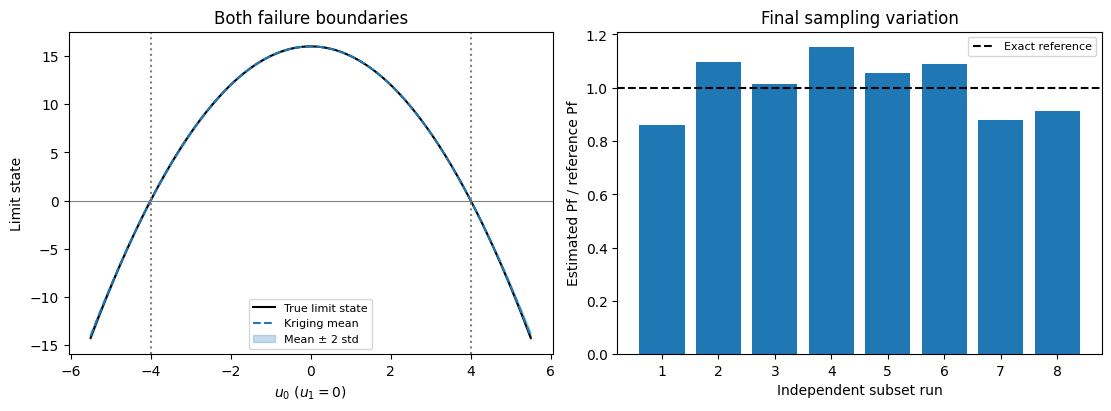

,Level,Threshold,Conditional probability,Acceptance,Chain variance factor
0,0,13.33,0.1,1,1
1,1,9.56486,0.1,0.577222,2.22779
2,2,5.43084,0.1,0.442222,2.78474
3,3,1.10412,0.1005,0.353333,2.99419
4,4,0,0.543,0.284603,5.27331


In [4]:
axis = np.linspace(-5.5, 5.5, 301)
points = np.column_stack((axis, np.zeros(len(axis))))
mean, std = tail_analysis.surrogate_model.predict(points)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(axis, 16-axis**2, color="black", label="True limit state")
axes[0].plot(axis, mean, "--", color="tab:blue", label="Kriging mean")
axes[0].fill_between(axis, mean-2*std, mean+2*std, alpha=0.25,
                     color="tab:blue", label="Mean ± 2 std")
axes[0].axhline(0, color="grey", linewidth=0.8)
for boundary in (-4, 4): axes[0].axvline(boundary, color="grey", linestyle=":")
axes[0].set(xlabel="$u_0$ ($u_1=0$)", ylabel="Limit state", title="Both failure boundaries")
axes[0].legend(fontsize=8)
replicates = [run.failure_probability for run in tail_result.estimate.diagnostics]
axes[1].bar(np.arange(1, len(replicates)+1), np.array(replicates)/tail_reference,
            color="tab:blue")
axes[1].axhline(1, color="black", linestyle="--", label="Exact reference")
axes[1].set(xlabel="Independent subset run", ylabel="Estimated Pf / reference Pf",
            title="Final sampling variation")
axes[1].legend(fontsize=8)
plt.show()

pd.DataFrame([
    {"Level": index, "Threshold": level.threshold,
     "Conditional probability": level.conditional_probability,
     "Acceptance": level.acceptance_rate,
     "Chain variance factor": level.variance_factor}
    for index, level in enumerate(tail_result.estimate.diagnostics[0].levels)
])

## Independent checks in both tails

Ordinary Monte Carlo would give few validation failures at this probability.
Instead, draw validation points from the equal mixture
$q(u_0)=\tfrac12\phi(u_0-4)+\tfrac12\phi(u_0+4)$, with $u_1\sim N(0,1)$.
The weight $\phi(u_0)/q(u_0)$ converts misclassified fractions back to the
original normal probability measure. This independent validation calculation
is not an active importance-sampling estimator.

The regression tests use seeds 7, 23 and 101, limit total misclassified mass
to 10% of reference Pf, and missed mass in each tail to 5%. The classical
four-branch example is also tested, including all four failure regions.
These are benchmark acceptance budgets, not universal error guarantees.

In [5]:
rng = np.random.default_rng(892)
validation = rng.normal(size=(100_000, 2))
validation[:, 0] += rng.choice([-4, 4], size=len(validation))
log_proposal = logsumexp(np.stack((
    norm.logpdf(validation[:, 0]-4), norm.logpdf(validation[:, 0]+4),
)), axis=0)-np.log(2)
weights = np.exp(norm.logpdf(validation[:, 0])-log_proposal)
truth = 16-validation[:, 0]**2 <= 0
prediction = np.concatenate([
    tail_analysis.surrogate_model.predict(batch)[0]
    for batch in np.array_split(validation, 50)
]) <= 0
misclassified = np.mean(weights*(truth != prediction))
assert misclassified < 0.1*tail_reference
validation_results = []
for name, region in (("Left tail", validation[:, 0] < -4),
                     ("Right tail", validation[:, 0] > 4)):
    missed = np.mean(weights*region*(~prediction))
    assert missed < 0.05*tail_reference
    validation_results.append({"Region": name, "Missed probability mass": missed,
                               "Fraction of total reference Pf": missed/tail_reference})
print(f"Total misclassified mass / reference Pf: {misclassified/tail_reference:.3%}")
pd.DataFrame(validation_results)

Total misclassified mass / reference Pf: 0.454%


,Region,Missed probability mass,Fraction of total reference Pf
0,Left tail,7.29319e-08,0.00115139
1,Right tail,2.67232e-08,0.000421885


## Why pooled subset counts cannot estimate Pf

Conditional populations deliberately concentrate near failure. Their raw
failure fraction is not a normal-space probability. The estimator therefore
returns selection points separately from its probability and beta diagnostics.
During exploration the mean ± 2 std failure events are nested within the same
positive-threshold subsets of mean - 2 std. A common prefix probability times
each final conditional fraction supplies the ordered band.

Common random numbers are used between fits to reduce sampling noise in
convergence comparisons. Final estimation uses a separate random stream.

In [6]:
exploration = tail_analysis.estimator.explore(
    tail_analysis.surrogate_model.predict, dimension=2,
    rng=np.random.default_rng(42), n_candidates=5000,
)
pd.DataFrame([{
    "Raw pooled fraction (not Pf)": np.mean(exploration.mean <= 0),
    "Subset Pf estimate": exploration.estimate.failure_probability,
    "Exploratory probability band": exploration.probability_band,
    "Reference Pf": tail_reference,
}])

,Raw pooled fraction (not Pf),Subset Pf estimate,Exploratory probability band,Reference Pf
0,0.095,6.53169e-05,"(6.306936718750003e-05, 6.802441406250002e-05)",6.33425e-05


## Budget failure stays visible

Subset simulation must reach the target failure event before its estimate can
be accepted. An inadequate level budget returns an incomplete record with
infinite sampling CoV. A stalled positive threshold behaves similarly. The
active runner can continue enrichment after incomplete exploration, but cannot
report convergence from it. An independent final-estimator failure appears as
`estimation_failed` after otherwise successful surrogate stopping.

Increasing sample size or replication count improves sampling precision;
increasing `max_levels` permits rarer events. Neither replaces independent
surrogate validation. The legacy standalone `pystra.SubsetSimulation` remains
available as a baseline with its documented correlation-omitting CoV.

In [7]:
unfinished = SubsetSimulationEstimator(n_samples=100, max_levels=1).estimate(
    lambda points: (5-points[:, 0], np.zeros(len(points))),
    dimension=2, rng=np.random.default_rng(7),
)
assert not unfinished.converged
assert unfinished.status == "max_levels"
assert np.isinf(unfinished.sampling_cov)
print(f"Completed: {unfinished.converged}; status: {unfinished.status}; CoV: {unfinished.sampling_cov}")

Completed: False; status: max_levels; CoV: inf
